<a href="https://colab.research.google.com/github/solosolve-ai/solosolve-ai/blob/main/Gemma3FineTune_(5)_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

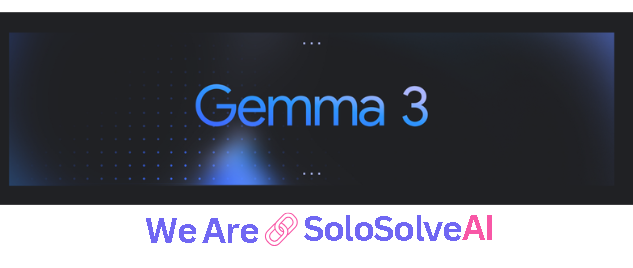

In [1]:
# Cell 1: PyTorch and CUDA Version Check
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA not available. Training will run on CPU (very slow).")

PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
GPU Name: Tesla T4
GPU Memory: 14.74 GB


In [2]:
# Cell 2: Installs (Corrected)
# Pinning transformers to a version known to work with Gemma 3.
# Added "deepspeed>=0.14.0" to resolve the ImportError with the Trainer.
!pip install -q "transformers==4.50.0" "datasets>=2.14.0" "peft>=0.7.0" "trl>=0.7.0" "accelerate>=0.25.0" "bitsandbytes>=0.41.3" "deepspeed>=0.14.0" sentencepiece huggingface_hub scikit-learn pandas matplotlib seaborn evaluate rouge_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.4/366.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.4 MB/s eta 0:00:00


In [3]:
# Cell 3: Hugging Face Login
from huggingface_hub import login, HfFolder
import os

# --- Hugging Face Login ---
# It's better to store the token as an environment variable or use notebook_login() for interactive login.
# For non-interactive environments, ensure the token is securely managed.
# hf_token_value = "YOUR_HF_TOKEN_HERE" # Replace with your token or set as environment variable
hf_token_value = "_"# Example: Read from env var

if hf_token_value:
    try:
        login(token=hf_token_value)
        print("Hugging Face login successful (using provided token).")
    except Exception as e:
        print(f"Hugging Face login failed with provided token: {e}.")
        print("Please ensure your Hugging Face token is correct and has 'write' permissions if you plan to push models.")
        print("You can login manually using `from huggingface_hub import notebook_login; notebook_login()` in a new cell.")
else:
    print("Hugging Face token not provided. Login manually if needed for private models or pushing to hub.")
    # from huggingface_hub import notebook_login
    # notebook_login()

Hugging Face login failed with provided token: Invalid user token..
Please ensure your Hugging Face token is correct and has 'write' permissions if you plan to push models.
You can login manually using `from huggingface_hub import notebook_login; notebook_login()` in a new cell.


In [4]:
# Cell 4: Imports and Main Configuration (Final Corrected Version)

import torch
from packaging.version import parse

# --- Environment Sanity Check ---
if parse(torch.__version__) < parse("2.2.0"):
    raise ImportError(
        f"Your loaded PyTorch version is {torch.__version__}, but the required transformers version needs PyTorch >= 2.2.0.\n\n"
        "SOLUTION: Please restart your notebook kernel/runtime now and run all cells from the beginning."
    )

# --- Imports (CORRECTED to include PEFT) ---
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
    logging as hf_logging
)
# CORRECTED: Added missing imports for PEFT/QLoRA
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset, Dataset
import os
import json
import gc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from typing import Dict, List, Optional, Union
import re
from tqdm.auto import tqdm
import traceback
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate as hf_evaluate

# --- Configuration & Paths ---
NOTEBOOK_DIR = "."
SFT_DATASET_PATH = "/content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv"
STUDENT_MODEL_ID = "google/gemma-3-270m"

FINE_TUNED_MODEL_DIR_BASE = os.path.join(NOTEBOOK_DIR, "gemma-3-270m-fashion-multitask")
run_version = 1
while os.path.exists(f"{FINE_TUNED_MODEL_DIR_BASE}_v{run_version}"):
    run_version += 1
FINE_TUNED_MODEL_DIR = f"{FINE_TUNED_MODEL_DIR_BASE}_v{run_version}"

LORA_ADAPTER_DIR = os.path.join(FINE_TUNED_MODEL_DIR, "lora_adapter")
CLASSIFICATION_HEADS_PATH = os.path.join(FINE_TUNED_MODEL_DIR, "classification_heads.pth")
TOKENIZER_SAVE_PATH = os.path.join(FINE_TUNED_MODEL_DIR, "tokenizer")
OUTPUT_DIR_TRAINER_LOGS = os.path.join(FINE_TUNED_MODEL_DIR, "trainer_output_logs")
EVAL_RESULTS_DIR = os.path.join(FINE_TUNED_MODEL_DIR, "evaluation_results")

for path in [FINE_TUNED_MODEL_DIR, LORA_ADAPTER_DIR, TOKENIZER_SAVE_PATH, OUTPUT_DIR_TRAINER_LOGS, EVAL_RESULTS_DIR]:
    os.makedirs(path, exist_ok=True)

print(f"SFT Data Path: {SFT_DATASET_PATH}")
print(f"Student Model ID: {STUDENT_MODEL_ID}")
print(f"Artifacts will be saved to: {FINE_TUNED_MODEL_DIR}")

# --- Fine-Tuning Hyperparameters ---
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
NUM_TRAIN_EPOCHS = 1
PER_DEVICE_TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 0.3
WARMUP_RATIO = 0.03
LR_SCHEDULER_TYPE = "cosine"
OPTIM = "paged_adamw_8bit"
LOGGING_STEPS = 10
SAVE_STRATEGY = "epoch"
PER_DEVICE_EVAL_BATCH_SIZE = PER_DEVICE_TRAIN_BATCH_SIZE
USE_4BIT_QUANTIZATION = True
USE_NESTED_QUANTIZATION = False
BNB_4BIT_COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
GRADIENT_CHECKPOINTING = True
GC_KWARGS = {"use_reentrant": False}
MAX_SEQ_LENGTH_TRAINING = 2048
SEED = 42
ATTN_IMPL_TRAINING = 'eager'

# --- Core Lists & Label Mappings ---
COMPLAINT_CATEGORIES = ["Damaged or Defective", "Item Not as Described", "Incorrect Size / Fit", "Wrong or Incomplete Order", "N/A"]
RESOLUTION_RECOMMENDATIONS = ["Full Refund", "Replacement", "Resend", "N/A"]

ACTIONABLE_MAP = {True: 1, False: 0, 1: 1, 0: 0, "1": 1, "0": 0}
INFO_COMPLETE_MAP = {True: 1, False: 0, 1: 1, 0: 0, "1": 1, "0": 0}
COMPLAINT_CATEGORY_MAP = {cat: i for i, cat in enumerate(COMPLAINT_CATEGORIES)}
RESOLUTION_RECOMMENDATION_MAP = {dec: i for i, dec in enumerate(RESOLUTION_RECOMMENDATIONS)}

num_labels_dict_global = {
    "is_actionable": 2,
    "info_complete": 2,
    "complaint_category": len(COMPLAINT_CATEGORY_MAP),
    "resolution_recommendation": len(RESOLUTION_RECOMMENDATION_MAP),
}
print(f"Number of classes for heads: {num_labels_dict_global}")

# --- Final Setup ---
LOG_LEVEL = hf_logging.INFO
hf_logging.set_verbosity(LOG_LEVEL)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}")

if not os.path.exists(SFT_DATASET_PATH):
    print(f"SFT dataset not found at {SFT_DATASET_PATH}. Creating a dummy CSV for demonstration.")
    dummy_data = []
    for i in range(100):
        dummy_entry = {
            'text': f"Customer complaint {i}: The item arrived broken and I am very unhappy.",
            'product_title': f"Dummy Product {i}",
            'price': 25.99,
            'rating': (i % 2) + 1,
            'info_complete': i % 2,
            'is_actionable': i % 2,
            'complaint_category': COMPLAINT_CATEGORIES[i % len(COMPLAINT_CATEGORIES)],
            'resolution_recommendation': RESOLUTION_RECOMMENDATIONS[i % len(RESOLUTION_RECOMMENDATIONS)],
        }
        dummy_data.append(dummy_entry)
    pd.DataFrame(dummy_data).to_csv(SFT_DATASET_PATH, index=False)
    print(f"Dummy SFT CSV with {len(dummy_data)} entries created at {SFT_DATASET_PATH}")

SFT Data Path: /content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv
Student Model ID: google/gemma-3-270m
Artifacts will be saved to: ./gemma-3-270m-fashion-multitask_v1
Number of classes for heads: {'is_actionable': 2, 'info_complete': 2, 'complaint_category': 5, 'resolution_recommendation': 4}
Training on: cuda


In [5]:
# Cell 5: Custom Multi-Task Model Class (Final Version with All Compatibility Methods)

import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig
from typing import Dict, List, Optional, Union

class GemmaComplaintResolver(nn.Module):
    def __init__(self, base_model_name_or_path, num_labels_dict, model_config_for_base_loading, dropout_rate=0.1):
        super().__init__()

        global USE_4BIT_QUANTIZATION, USE_NESTED_QUANTIZATION, BNB_4BIT_COMPUTE_DTYPE, DEVICE
        global ATTN_IMPL_TRAINING, GRADIENT_CHECKPOINTING, GC_KWARGS, num_labels_dict_global

        if USE_4BIT_QUANTIZATION:
            bnb_config_runtime = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=USE_NESTED_QUANTIZATION,
                bnb_4bit_compute_dtype=BNB_4BIT_COMPUTE_DTYPE,
            )
            torch_dtype_runtime = None
            print(f"GCR: QLoRA enabled. Using device_map='auto' and compute_dtype={BNB_4BIT_COMPUTE_DTYPE}")
        elif torch.cuda.is_available():
            torch_dtype_runtime = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
            print(f"GCR: No QLoRA. Using torch_dtype: {torch_dtype_runtime} on GPU with device_map='auto'.")
        else:
            torch_dtype_runtime = torch.float32
            print(f"GCR: No QLoRA. Using float32 on CPU.")

        self.base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name_or_path,
            config=model_config_for_base_loading,
            quantization_config=bnb_config_runtime,
            torch_dtype=torch_dtype_runtime,
            attn_implementation=ATTN_IMPL_TRAINING,
            trust_remote_code=True,
            device_map="auto"
        )

        hidden_size = self.base_model.config.hidden_size
        print(f"GCR: Base model loaded. Hidden_size: {hidden_size}")

        self.dropout = nn.Dropout(dropout_rate)
        self.head_is_actionable = nn.Linear(hidden_size, num_labels_dict_global["is_actionable"])
        self.head_complaint_category = nn.Linear(hidden_size, num_labels_dict_global["complaint_category"])
        self.head_resolution_recommendation = nn.Linear(hidden_size, num_labels_dict_global["resolution_recommendation"])
        self.head_info_complete = nn.Linear(hidden_size, num_labels_dict_global["info_complete"])
        self.criterion_classification = nn.CrossEntropyLoss(ignore_index=-100)

    # --- Pass-through methods for Hugging Face compatibility ---
    def prepare_inputs_for_generation(self, *args, **kwargs):
        return self.base_model.prepare_inputs_for_generation(*args, **kwargs)

    @property
    def config(self):
        return self.base_model.config

    @property
    def device(self):
        return self.base_model.device

    # NEWLY ADDED: Required by the Trainer when gradient_checkpointing is enabled.
    def gradient_checkpointing_enable(self, *args, **kwargs):
        """Delegates gradient checkpointing enabling to the base model."""
        if hasattr(self.base_model, "gradient_checkpointing_enable"):
            self.base_model.gradient_checkpointing_enable(*args, **kwargs)

    def gradient_checkpointing_disable(self, *args, **kwargs):
        """Delegates gradient checkpointing disabling to the base model."""
        if hasattr(self.base_model, "gradient_checkpointing_disable"):
            self.base_model.gradient_checkpointing_disable(*args, **kwargs)
    # --- END OF ADDITIONS ---

    def forward(self, input_ids, attention_mask=None, labels=None,
                label_is_actionable=None, label_complaint_category=None,
                label_resolution_recommendation=None, label_info_complete=None, **kwargs):

        transformer_outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            output_hidden_states=True,
            return_dict=True
        )
        lm_loss = transformer_outputs.loss
        last_hidden_state = transformer_outputs.hidden_states[-1]

        if attention_mask is not None:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            pooled_output = last_hidden_state[torch.arange(last_hidden_state.size(0), device=last_hidden_state.device), sequence_lengths]
        else:
            pooled_output = last_hidden_state[:, -1, :]

        pooled_output = self.dropout(pooled_output)

        logits_is_actionable = self.head_is_actionable(pooled_output)
        logits_complaint_category = self.head_complaint_category(pooled_output)
        logits_resolution_recommendation = self.head_resolution_recommendation(pooled_output)
        logits_info_complete = self.head_info_complete(pooled_output)

        total_loss = torch.tensor(0.0, device=input_ids.device)
        if lm_loss is not None:
            total_loss += lm_loss

        def _add_cls_loss(logits, target_labels):
            nonlocal total_loss
            if target_labels is not None:
                cls_loss = self.criterion_classification(logits.view(-1, logits.size(-1)), target_labels.view(-1).to(logits.device))
                if not torch.isnan(cls_loss):
                    total_loss += cls_loss

        _add_cls_loss(logits_is_actionable, label_is_actionable)
        _add_cls_loss(logits_complaint_category, label_complaint_category)
        _add_cls_loss(logits_resolution_recommendation, label_resolution_recommendation)
        _add_cls_loss(logits_info_complete, label_info_complete)

        return {
            "loss": total_loss,
            "logits_is_actionable": logits_is_actionable,
            "logits_complaint_category": logits_complaint_category,
            "logits_resolution_recommendation": logits_resolution_recommendation,
            "logits_info_complete": logits_info_complete,
        }

print("GemmaComplaintResolver class defined with full compatibility methods.")

GemmaComplaintResolver class defined with full compatibility methods.


In [6]:
# Cell 6: Load and Prepare SFT Dataset (Corrected for Missing Data)

# --- 1. Install Polars ---
!pip install -q polars

# --- 2. Imports and Setup ---
import polars as pl
import json
import traceback
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoConfig
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Initialize variables to be safe
tokenizer = None
processed_train_dataset = None
processed_eval_dataset = None
model_config_for_tokens = None

# --- 3. Load Data and Tokenizer ---
try:
    if not os.path.exists(SFT_DATASET_PATH):
        raise FileNotFoundError(f"SFT dataset file not found: {SFT_DATASET_PATH}.")

    # Use Polars to read the CSV data
    sft_df = pl.read_csv(SFT_DATASET_PATH)
    print(f"Loaded {sft_df.height} raw entries with Polars from {SFT_DATASET_PATH}.")

    # NEW: Proactively fill nulls in key text columns to prevent downstream errors.
    sft_df = sft_df.with_columns([
        pl.col("text").fill_null("").alias("text"),
        pl.col("product_title").fill_null("").alias("product_title")
    ])

    # Split into training and evaluation sets
    train_df, eval_df = train_test_split(sft_df.to_pandas(), test_size=0.1, random_state=SEED, shuffle=True)
    train_dataset_raw = Dataset.from_pandas(train_df)
    eval_dataset_raw = Dataset.from_pandas(eval_df)

    print(f"Raw train samples: {len(train_dataset_raw)}, Raw eval samples: {len(eval_dataset_raw)}")

    # Load tokenizer and config
    print(f"Loading Tokenizer: {STUDENT_MODEL_ID}")
    tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
    model_config_for_tokens = AutoConfig.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)

    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    print(f"Tokenizer setup complete. PAD token is set to EOS token: {tokenizer.pad_token}")

except Exception as e:
    print(f"Error in data loading or tokenizer setup: {e}")
    traceback.print_exc()
    raise RuntimeError("Failed to load data or tokenizer.") from e

# --- 4. Prompt and Label Processing Functions (CORRECTED) ---

def create_prompt(row: dict) -> str:
    """Constructs a detailed input prompt, safely handling potentially missing price data."""
    # CORRECTED: Safely format the price to handle None/null values.
    price_val = row.get('price')
    try:
        price_str = f"${float(price_val):.2f}"
    except (ValueError, TypeError):
        price_str = "N/A" # Default to "N/A" if price is missing or not a number

    template = (
        "Analyze the following customer complaint about an Amazon Fashion product.\n\n"
        "### Product Information ###\n"
        f"Title: {row.get('product_title', 'N/A')}\n"
        f"Price: {price_str}\n"
        f"Customer's Rating: {row.get('rating', 'N/A')}/5\n\n"
        "### Customer Complaint ###\n"
        f"Text: \"{row.get('text', '')}\""
    )
    return template

def process_sft_example_multitask(example: Dict) -> Dict:
    """Processes a single example from the dataset to create the final training format."""
    global tokenizer
    input_prompt = create_prompt(example)
    prompt_for_masking = f"<start_of_turn>user\n{input_prompt}<end_of_turn>\n<start_of_turn>model\n"

    ignore_val = -100
    labels_dict = {
        'label_is_actionable': ACTIONABLE_MAP.get(example.get('is_actionable'), ignore_val),
        'label_info_complete': INFO_COMPLETE_MAP.get(example.get('info_complete'), ignore_val),
        'label_complaint_category': COMPLAINT_CATEGORY_MAP.get(example.get('complaint_category'), ignore_val),
        'label_resolution_recommendation': RESOLUTION_RECOMMENDATION_MAP.get(example.get('resolution_recommendation'), ignore_val)
    }

    target_json_string = json.dumps({
        "complaint_category": example.get('complaint_category', "N/A"),
        "resolution_recommendation": example.get('resolution_recommendation', "N/A"),
        "is_actionable": bool(example.get('is_actionable')),
        "info_complete": bool(example.get('info_complete')),
    }, ensure_ascii=False)

    full_text_for_lm = prompt_for_masking + target_json_string + tokenizer.eos_token
    tokenized_prompt = tokenizer(prompt_for_masking, add_special_tokens=False)
    prompt_length_for_masking = len(tokenized_prompt['input_ids'])

    return {
        "text_for_lm": full_text_for_lm,
        "prompt_length_for_masking": prompt_length_for_masking,
        **labels_dict
    }

# --- 5. Apply Processing to Datasets ---
if train_dataset_raw and tokenizer:
    print("\nProcessing training data for multi-task format...")
    processed_train_dataset = train_dataset_raw.map(
        process_sft_example_multitask,
        remove_columns=train_dataset_raw.column_names
    )
    print(f"Processed train dataset: {len(processed_train_dataset)} samples.")
    print(f"New Columns: {processed_train_dataset.column_names}")

    if eval_dataset_raw:
        print("\nProcessing evaluation data for multi-task format...")
        processed_eval_dataset = eval_dataset_raw.map(
            process_sft_example_multitask,
            remove_columns=eval_dataset_raw.column_names
        )
        print(f"Processed eval dataset: {len(processed_eval_dataset)} samples.")
    else:
        processed_eval_dataset = None
else:
    print("Skipping data processing: missing raw training data or tokenizer.")

Loaded 4545 raw entries with Polars from /content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv.
Raw train samples: 4090, Raw eval samples: 455
Loading Tokenizer: google/gemma-3-270m


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Tokenizer setup complete. PAD token is set to EOS token: <eos>

Processing training data for multi-task format...


Map:   0%|          | 0/4090 [00:00<?, ? examples/s]

Processed train dataset: 4090 samples.
New Columns: ['text_for_lm', 'prompt_length_for_masking', 'label_is_actionable', 'label_info_complete', 'label_complaint_category', 'label_resolution_recommendation']

Processing evaluation data for multi-task format...


Map:   0%|          | 0/455 [00:00<?, ? examples/s]

Processed eval dataset: 455 samples.


In [7]:
# Cell 7: Custom Data Collator
from transformers import DataCollatorForLanguageModeling
from typing import List, Dict
import torch

global MAX_SEQ_LENGTH_TRAINING # Ensure this is accessible

class MultiTaskDataCollator(DataCollatorForLanguageModeling):
    def __init__(self, tokenizer, mlm=False, max_length=None):
        super().__init__(tokenizer=tokenizer, mlm=mlm)

        global MAX_SEQ_LENGTH_TRAINING
        effective_max_length = tokenizer.model_max_length
        if hasattr(tokenizer, 'max_len_single_sentence') and tokenizer.max_len_single_sentence is not None:
             effective_max_length = min(effective_max_length, tokenizer.max_len_single_sentence)

        self.max_length = max_length if max_length is not None else effective_max_length
        cap_length = MAX_SEQ_LENGTH_TRAINING if 'MAX_SEQ_LENGTH_TRAINING' in globals() and MAX_SEQ_LENGTH_TRAINING is not None else 2048

        if self.max_length > cap_length :
            print(f"DataCollator: Initial max_length ({self.max_length}) > training_cap ({cap_length}). Capping to {cap_length}.")
            self.max_length = cap_length
        print(f"MultiTaskDataCollator initialized with max_length: {self.max_length}")
        self.debug_collator_counter = 0


    def __call__(self, examples: List[Dict]) -> Dict[str, torch.Tensor]:
        full_sequences = [ex["text_for_lm"] for ex in examples]
        prompt_lengths_for_masking = [ex["prompt_length_for_masking"] for ex in examples]

        batch_tokenized = self.tokenizer(
            full_sequences,
            padding="longest",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        batch = {
            "input_ids": batch_tokenized["input_ids"],
            "attention_mask": batch_tokenized["attention_mask"]
        }
        lm_labels = batch["input_ids"].clone()

        for i in range(len(examples)):
            example_id_for_debug = examples[i].get("id", f"unknown_id_idx_{i}")
            prompt_len_tokens_from_example = prompt_lengths_for_masking[i]
            actual_input_ids_for_example = batch_tokenized["input_ids"][i]
            batch_seq_len = lm_labels.size(1) # Max length in this specific batch after padding/truncation

            # Actual content length for this specific example in the batch (excluding padding)
            current_example_content_length = actual_input_ids_for_example.ne(self.tokenizer.pad_token_id).sum().item()

            initial_mask_end_idx = prompt_len_tokens_from_example
            final_mask_end_idx = initial_mask_end_idx # Start with this

            # Check if BOS token was prepended by the main tokenizer call
            bos_was_prepended = False
            if self.tokenizer.bos_token_id is not None and \
               actual_input_ids_for_example[0] == self.tokenizer.bos_token_id:
                bos_was_prepended = True
                final_mask_end_idx = 1 + prompt_len_tokens_from_example # Mask BOS + original prompt tokens

            # Ensure mask_end_idx does not exceed the actual content length of this example or the batch's max sequence length
            final_mask_end_idx = min(final_mask_end_idx, current_example_content_length)
            final_mask_end_idx = min(final_mask_end_idx, batch_seq_len) # Defensive

            if self.debug_collator_counter < 5 * len(examples) : # Print for first few batches
                print(f"\n--- Collator Debug for Example ID: {example_id_for_debug} (Batch item {i}, Global collator count: {self.debug_collator_counter}) ---")
                print(f"  Received prompt_length_from_example: {prompt_len_tokens_from_example}")
                print(f"  Batch max sequence_len (lm_labels.size(1)): {batch_seq_len}")
                print(f"  This example's actual content_length (no pad): {current_example_content_length}")
                print(f"  BOS token prepended by main tokenizer: {bos_was_prepended} (BOS ID: {self.tokenizer.bos_token_id}, First token: {actual_input_ids_for_example[0].item()})")
                print(f"  Mask end index before min ops (initial_mask_end_idx if no BOS, 1+initial if BOS): {1 + prompt_len_tokens_from_example if bos_was_prepended else prompt_len_tokens_from_example}")
                print(f"  Final mask_end_idx (after min with content_length & batch_seq_len): {final_mask_end_idx}")

                if final_mask_end_idx > 0:
                    masked_tokens_decoded = self.tokenizer.decode(actual_input_ids_for_example[:final_mask_end_idx], skip_special_tokens=False)
                    unmasked_tokens_decoded = self.tokenizer.decode(actual_input_ids_for_example[final_mask_end_idx:current_example_content_length], skip_special_tokens=False)
                    print(f"  Tokens to be masked (decoded, first 70 chars): '{masked_tokens_decoded[:70]}...'")
                    print(f"  Tokens to be UNMASKED (target, first 70 chars): '{unmasked_tokens_decoded[:70]}...'")
                else:
                    print(f"  No tokens will be masked for prompt (final_mask_end_idx is {final_mask_end_idx}).")

                if final_mask_end_idx >= current_example_content_length and current_example_content_length > 0 :
                     print(f"  CRITICAL_COLLATOR_DEBUG: final_mask_end_idx ({final_mask_end_idx}) >= current_example_content_length ({current_example_content_length}). All content tokens will be masked!")
                self.debug_collator_counter +=1

            if final_mask_end_idx > 0:
                lm_labels[i, :final_mask_end_idx] = -100
            elif prompt_len_tokens_from_example > 0: # If prompt had length but nothing is masked
                 if self.debug_collator_counter < 10 * len(examples): # Print for a bit longer if this happens
                    print(f"  Warning (DataCollator): Prompt length was {prompt_len_tokens_from_example} but final_mask_end_idx is {final_mask_end_idx} for example {example_id_for_debug}. No LM masking applied for prompt part.")


        if self.tokenizer.pad_token_id is not None:
            lm_labels[lm_labels == self.tokenizer.pad_token_id] = -100

        batch["labels"] = lm_labels

        if torch.all(lm_labels == -100) and lm_labels.numel() > 0 : # Check if not an empty tensor
            if self.debug_collator_counter < 10 * len(examples) or (self.debug_collator_counter % 100 ==0) : # Print more often if this persists
                print(f"Warning (DataCollator): All LM labels are -100 for this batch. Batch size: {len(examples)}. Example 0 input_ids (first 30): {batch['input_ids'][0, :30]}... Example 0 labels (first 30): {lm_labels[0, :30]}...")

        label_keys = [k for k in examples[0].keys() if k.startswith('label_')]
        for key in label_keys:
            label_values = [ex.get(key, -100) for ex in examples]
            try:
                batch[key] = torch.tensor(label_values, dtype=torch.long).to(batch['input_ids'].device)
            except Exception as e: # Simplified, original had more logging here
                print(f"Error converting labels for key {key} to tensor: {e}")
                batch[key] = torch.full((len(examples),), -100, dtype=torch.long).to(batch['input_ids'].device)
        return batch

print("MultiTaskDataCollator defined with extensive debugging prints.")

MultiTaskDataCollator defined with extensive debugging prints.


In [8]:
# Cell 8: Model Instantiation & LoRA
model = None

if tokenizer and processed_train_dataset and len(processed_train_dataset) > 0 :
    try:
        print(f"Loading base model '{STUDENT_MODEL_ID}' for multi-task fine-tuning...")
        model_config_main = AutoConfig.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)

        model_multitask = GemmaComplaintResolver(
            base_model_name_or_path=STUDENT_MODEL_ID,
            num_labels_dict=num_labels_dict_global,
            model_config_for_base_loading=model_config_main,
        )
        print("GemmaComplaintResolver instantiated.")

        if USE_4BIT_QUANTIZATION:
            print("Preparing base_model component for k-bit training...")
            # model_multitask.base_model is the AutoModelForCausalLM instance
            # prepare_model_for_kbit_training will enable GC on this if GRADIENT_CHECKPOINTING is True
            model_multitask.base_model = prepare_model_for_kbit_training(
                model_multitask.base_model,
                use_gradient_checkpointing=GRADIENT_CHECKPOINTING
            )
            print("Base model component prepared for k-bit training.")
            # prepare_model_for_kbit_training also sets use_cache=False if GC is enabled.
            if GRADIENT_CHECKPOINTING and hasattr(model_multitask.base_model.config, 'use_cache') and model_multitask.base_model.config.use_cache:
                 print("Warning: use_cache is True after prepare_model_for_kbit_training with GC. Forcing False.")
                 model_multitask.base_model.config.use_cache = False
            elif GRADIENT_CHECKPOINTING:
                 print("QLoRA with GC: use_cache should be False on base_model.config (handled by prepare_model_for_kbit_training).")


        if not USE_4BIT_QUANTIZATION and next(model_multitask.parameters()).device.type == 'cpu' and DEVICE.type == 'cuda':
             print(f"Moving model_multitask (non-QLoRA) to {DEVICE} before PEFT...")
             model_multitask = model_multitask.to(DEVICE)
             print(f"model_multitask is now on device: {next(model_multitask.parameters()).device}")

        lora_config_obj = LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            target_modules=LORA_TARGET_MODULES,
            lora_dropout=LORA_DROPOUT,
            bias="none",
            task_type="CAUSAL_LM"
        )

        model = get_peft_model(model_multitask, lora_config_obj)
        print("LoRA applied to GemmaComplaintResolver.")
        model.print_trainable_parameters()

        if str(model.device) != str(DEVICE) and DEVICE.type == "cuda":
            print(f"Moving final PeftModel from {model.device} to {DEVICE}...")
            model = model.to(DEVICE)
        print(f"Full PeftModel is on device: {model.device}")

        if hasattr(model, 'base_model') and isinstance(model.base_model, GemmaComplaintResolver):
            resolver_instance_check = model.base_model
            for head_name_attr_check in num_labels_dict_global.keys():
                actual_head_attr = f"head_{head_name_attr_check}"
                if hasattr(resolver_instance_check, actual_head_attr):
                    head_module_check = getattr(resolver_instance_check, actual_head_attr)
                    try:
                        if next(head_module_check.parameters()).device != model.device:
                             head_module_check.to(model.device)
                        # print(f"Device of {actual_head_attr}: {next(head_module_check.parameters()).device}") # Less verbose
                    except StopIteration:
                        pass # print(f"Head {actual_head_attr} has no parameters.")
                # else:
                    # print(f"Head attribute '{actual_head_attr}' not found for device check.")

        if GRADIENT_CHECKPOINTING:
            underlying_hf_model = model.base_model.base_model
            if hasattr(underlying_hf_model.config, 'use_cache'):
                if not underlying_hf_model.config.use_cache:
                    print("GC is ON and use_cache is correctly False on underlying LLM config.")
                else:
                    print("Warning: GC is ON but use_cache is True on underlying LLM config. Forcing False.")
                    underlying_hf_model.config.use_cache = False
            else:
                print("Warning: Could not verify use_cache on underlying LLM config for GC.")

    except Exception as e:
        print(f"Error during model setup: {e}")
        traceback.print_exc()
        model = None
else:
    print("Skipping model setup: missing tokenizer or data, or processed_train_dataset is empty.")

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/config.json
Model config Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 640,
  "initializer_range": 0.02,
  "intermediate_size": 2048,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    

Loading base model 'google/gemma-3-270m' for multi-task fine-tuning...
GCR: QLoRA enabled. Using device_map='auto' and compute_dtype=torch.bfloat16


Overriding torch_dtype=None with `torch_dtype=torch.float16` due to requirements of `bitsandbytes` to enable model loading in 8-bit or 4-bit. Pass your own torch_dtype to specify the dtype of the remaining non-linear layers or pass torch_dtype=torch.float16 to remove this warning.


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/model.safetensors
Instantiating Gemma3ForCausalLM model under default dtype torch.float16.
Generate config GenerationConfig {
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "eos_token_id": 1,
  "pad_token_id": 0
}

target_dtype {target_dtype} is replaced by `CustomDtype.INT4` for 4-bit BnB quantization
All model checkpoint weights were used when initializing Gemma3ForCausalLM.

All the weights of Gemma3ForCausalLM were initialized from the model checkpoint at google/gemma-3-270m.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Gemma3ForCausalLM for predictions without further training.


generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/generation_config.json
Generate config GenerationConfig {
  "cache_implementation": "hybrid",
  "do_sample": true,
  "top_k": 64,
  "top_p": 0.95
}



GCR: Base model loaded. Hidden_size: 640
GemmaComplaintResolver instantiated.
Preparing base_model component for k-bit training...
Base model component prepared for k-bit training.
LoRA applied to GemmaComplaintResolver.
trainable params: 3,796,992 || all params: 271,903,501 || trainable%: 1.3964
Moving final PeftModel from cuda:0 to cuda...
Full PeftModel is on device: cuda:0
GC is ON and use_cache is correctly False on underlying LLM config.


PyTorch: setting up devices



--- Configuring and Starting Multi-Task Training ---
Label names for Trainer: ['label_complaint_category', 'label_info_complete', 'label_is_actionable', 'label_resolution_recommendation', 'labels']
MultiTaskDataCollator initialized with max_length: 2048
[2025-09-14 14:11:42,714] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/tmp/ipython-input-1501747203.py:79: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[2025-09-14 14:11:47,454] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


Using auto half precision backend


...

Epoch,Training Loss,Validation Loss
0,0.232300,0.027949



***** Running Evaluation *****
  Num examples = 455
  Batch size = 1
Saving model checkpoint to ./gemma-3-270m-fashion-multitask_v1/trainer_output_logs/checkpoint-511
tokenizer config file saved in ./gemma-3-270m-fashion-multitask_v1/trainer_output_logs/checkpoint-511/tokenizer_config.json
Special tokens file saved in ./gemma-3-270m-fashion-multitask_v1/trainer_output_logs/checkpoint-511/special_tokens_map.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./gemma-3-270m-fashion-multitask_v1/trainer_output_logs/checkpoint-511 (score: 0.02794910967350006).
Saving model checkpoint to ./gemma-3-270m-fashion-multitask_v1/lora_adapter
tokenizer config file saved in ./gemma-3-270m-fashion-multitask_v1/lora_adapter/tokenizer_config.json
Special tokens file saved in ./gemma-3-270m-fashion-multitask_v1/lora_adapter/special_tokens_map.json


Training finished.
***** train metrics *****
  epoch                    =     0.9995
  total_flos               =        0GF
  train_loss               =     4.8901
  train_runtime            = 0:32:53.77
  train_samples_per_second =      2.072
  train_steps_per_second   =      0.259
Training metrics saved.


tokenizer config file saved in ./gemma-3-270m-fashion-multitask_v1/tokenizer/tokenizer_config.json
Special tokens file saved in ./gemma-3-270m-fashion-multitask_v1/tokenizer/special_tokens_map.json


Best LoRA adapter saved to ./gemma-3-270m-fashion-multitask_v1/lora_adapter
Saving classification head weights to ./gemma-3-270m-fashion-multitask_v1/classification_heads.pth...
Classification head weights saved.
Saving Tokenizer to ./gemma-3-270m-fashion-multitask_v1/tokenizer...
Tokenizer saved.

All artifacts for the best model are saved in ./gemma-3-270m-fashion-multitask_v1

--- Generating Training Visualizations ---
Training graphs saved to: ./gemma-3-270m-fashion-multitask_v1/evaluation_results/training_graphs.png


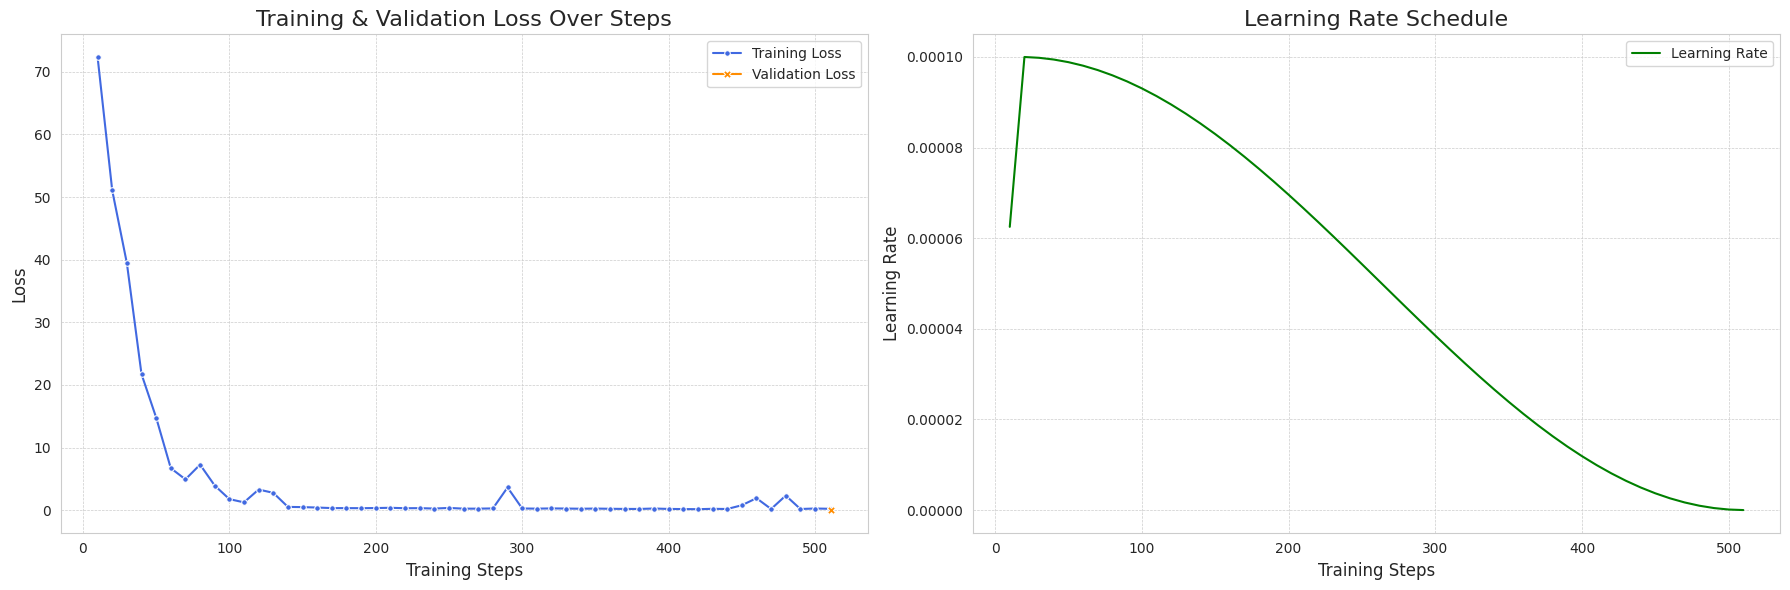


Cleaned up model and trainer from GPU memory.


In [9]:
# Cell 9: Trainer Setup, Execution & Visualization

# Assuming all necessary variables from previous cells are defined:
# model, processed_train_dataset, processed_eval_dataset, tokenizer,
# all configuration variables (e.g., NUM_TRAIN_EPOCHS, LEARNING_RATE),
# and all path variables (e.g., OUTPUT_DIR_TRAINER_LOGS, LORA_ADAPTER_DIR).

import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import TrainingArguments, Trainer

# MultiTaskDataCollator should be defined from Cell 7

if 'model' in locals() and model and \
   'processed_train_dataset' in locals() and processed_train_dataset and len(processed_train_dataset) > 0 and \
   'tokenizer' in locals() and tokenizer:

    print("\n--- Configuring and Starting Multi-Task Training ---")

    # Determine label names for the Trainer.
    # "labels" is for the LM task. "label_*" are for classification heads.
    label_names_for_trainer = ["labels"] # For Causal LM loss
    if processed_train_dataset.column_names:
        for col_name in processed_train_dataset.column_names:
            if col_name.startswith("label_"):
                label_names_for_trainer.append(col_name)

    label_names_for_trainer = sorted(list(set(label_names_for_trainer)))
    print(f"Label names for Trainer: {label_names_for_trainer}")

    # --- TWEAKED TrainingArguments ---
    # We now enable load_best_model_at_end for better generalization
    training_args_dict = {
        "output_dir": OUTPUT_DIR_TRAINER_LOGS,
        "num_train_epochs": NUM_TRAIN_EPOCHS,
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "optim": OPTIM,
        "save_strategy": SAVE_STRATEGY,
        "logging_steps": LOGGING_STEPS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "max_grad_norm": MAX_GRAD_NORM,
        "warmup_ratio": WARMUP_RATIO,
        "lr_scheduler_type": LR_SCHEDULER_TYPE,
        "report_to": "tensorboard",
        "eval_strategy": "epoch" if processed_eval_dataset and len(processed_eval_dataset) > 0 else "no",
        "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
        "gradient_checkpointing": GRADIENT_CHECKPOINTING,
        "remove_unused_columns": False, # Important: we need to keep all label columns for the custom model
        "label_names": label_names_for_trainer, # Explicitly tell Trainer which columns are labels
        "seed": SEED,
        # -- MODIFICATION FOR GENERALIZATION --
        "load_best_model_at_end": True if "epoch" in SAVE_STRATEGY or "steps" in SAVE_STRATEGY else False,
        "metric_for_best_model": "eval_loss", # Use eval loss to find the best model
        "save_total_limit": 2, # Save the best and the last checkpoint
    }

    if GRADIENT_CHECKPOINTING:
        training_args_dict["gradient_checkpointing_kwargs"] = GC_KWARGS

    if USE_4BIT_QUANTIZATION:
        training_args_dict["bf16"] = (BNB_4BIT_COMPUTE_DTYPE == torch.bfloat16)
        training_args_dict["fp16"] = (BNB_4BIT_COMPUTE_DTYPE == torch.float16)
    else:
        if DEVICE.type == 'cuda':
            runtime_bf16_supported = torch.cuda.is_bf16_supported()
            training_args_dict["bf16"] = runtime_bf16_supported
            training_args_dict["fp16"] = not runtime_bf16_supported
            print(f"Non-quantized training will use {'BF16' if runtime_bf16_supported else 'FP16'}.")

    training_args = TrainingArguments(**training_args_dict)

    collator = MultiTaskDataCollator(tokenizer=tokenizer, mlm=False, max_length=MAX_SEQ_LENGTH_TRAINING)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=processed_train_dataset,
        eval_dataset=processed_eval_dataset,
        tokenizer=tokenizer,
        data_collator=collator,
    )

    print("Trainer instantiated. Starting training...")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    train_result = None
    try:
        print("Starting trainer.train()...")
        train_result = trainer.train()
        print("Training finished.")

        trainer.log_metrics("train", train_result.metrics)
        trainer.save_metrics("train", train_result.metrics)
        print("Training metrics saved.")

        # Since load_best_model_at_end=True, trainer.save_model() will save the best model.
        # The underlying peft model's save_pretrained is called by trainer.save_model().
        trainer.save_model(LORA_ADAPTER_DIR)
        print(f"Best LoRA adapter saved to {LORA_ADAPTER_DIR}")

        # Manually save the classification heads from the best model
        print(f"Saving classification head weights to {CLASSIFICATION_HEADS_PATH}...")
        resolver_instance = trainer.model.base_model
        head_state_dict_to_save = {}
        for head_name in num_labels_dict_global.keys():
            head_attr = f"head_{head_name}"
            if hasattr(resolver_instance, head_attr):
                head_module = getattr(resolver_instance, head_attr)
                for param_name, param_value in head_module.state_dict().items():
                    head_state_dict_to_save[f"{head_attr}.{param_name}"] = param_value.cpu()

        if head_state_dict_to_save:
            torch.save(head_state_dict_to_save, CLASSIFICATION_HEADS_PATH)
            print("Classification head weights saved.")
        else:
            print("Warning: No classification head weights found to save.")

        print(f"Saving Tokenizer to {TOKENIZER_SAVE_PATH}...")
        tokenizer.save_pretrained(TOKENIZER_SAVE_PATH)
        print("Tokenizer saved.")
        print(f"\nAll artifacts for the best model are saved in {FINE_TUNED_MODEL_DIR}")

    except Exception as e:
        print(f"Error during training or saving: {e}")
        import traceback
        traceback.print_exc()

    # --- NEW: VISUALIZATION BLOCK ---
    if train_result and trainer.state.log_history:
        print("\n--- Generating Training Visualizations ---")
        try:
            log_df = pd.DataFrame(trainer.state.log_history)

            # Separate logs
            train_logs = log_df[log_df['loss'].notna()].copy()
            eval_logs = log_df[log_df['eval_loss'].notna()].copy()
            lr_logs = log_df[log_df['learning_rate'].notna()].copy()

            sns.set_style("whitegrid")
            plt.figure(figsize=(18, 6))

            # Plot 1: Training and Validation Loss
            ax1 = plt.subplot(1, 2, 1)
            if not train_logs.empty:
                sns.lineplot(data=train_logs, x='step', y='loss', label='Training Loss', ax=ax1, color='royalblue', marker='o', markersize=4)
            if not eval_logs.empty:
                sns.lineplot(data=eval_logs, x='step', y='eval_loss', label='Validation Loss', ax=ax1, color='darkorange', marker='X', markersize=6)
            ax1.set_title('Training & Validation Loss Over Steps', fontsize=16)
            ax1.set_xlabel('Training Steps', fontsize=12)
            ax1.set_ylabel('Loss', fontsize=12)
            ax1.legend()
            ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

            # Plot 2: Learning Rate Schedule
            ax2 = plt.subplot(1, 2, 2)
            if not lr_logs.empty:
                sns.lineplot(data=lr_logs, x='step', y='learning_rate', label='Learning Rate', ax=ax2, color='green')
            ax2.set_title('Learning Rate Schedule', fontsize=16)
            ax2.set_xlabel('Training Steps', fontsize=12)
            ax2.set_ylabel('Learning Rate', fontsize=12)
            ax2.legend()
            ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

            plt.tight_layout()

            # Save the figure
            plot_save_path = os.path.join(EVAL_RESULTS_DIR, "training_graphs.png")
            plt.savefig(plot_save_path, dpi=300)
            print(f"Training graphs saved to: {plot_save_path}")

            # Display the plots in the notebook
            plt.show()

        except Exception as e:
            print(f"Could not generate plots. Error: {e}")
            print("Log history from trainer state:")
            print(trainer.state.log_history)

    # --- END OF VISUALIZATION BLOCK ---

    # Final cleanup
    if 'model' in locals() and hasattr(model, 'device') and model.device.type == 'cuda':
        del model, trainer
        if 'model_multitask' in locals(): del model_multitask
        gc.collect()
        torch.cuda.empty_cache()
        print("\nCleaned up model and trainer from GPU memory.")

else:
    print("Training skipped: missing model, processed training data, or tokenizer.")

--- 1. Setting up for Evaluation ---


loading file tokenizer.model
loading file tokenizer.json
loading file added_tokens.json
loading file special_tokens_map.json
loading file tokenizer_config.json
loading file chat_template.jinja


Evaluation tasks: ['is_actionable', 'info_complete', 'complaint_category', 'resolution_recommendation']
Final model will be pushed to: https://huggingface.co/ShovalBenjer/gemma-3-270m-fashion-multitask_v1


loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/config.json
Model config Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 640,
  "initializer_range": 0.02,
  "intermediate_size": 2048,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    


--- Evaluating Fine-Tuned Model ---
Loading fine-tuned model...
GCR: QLoRA enabled. Using device_map='auto' and compute_dtype=torch.bfloat16


...


--- Evaluating Base Model (for comparison) ---
Loading base model...
GCR: QLoRA enabled. Using device_map='auto' and compute_dtype=torch.bfloat16


target_dtype {target_dtype} is replaced by `CustomDtype.INT4` for 4-bit BnB quantization
All model checkpoint weights were used when initializing Gemma3ForCausalLM.

All the weights of Gemma3ForCausalLM were initialized from the model checkpoint at google/gemma-3-270m.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Gemma3ForCausalLM for predictions without further training.
loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/generation_config.json
Generate config GenerationConfig {
  "cache_implementation": "hybrid",
  "do_sample": true,
  "top_k": 64,
  "top_p": 0.95
}



GCR: Base model loaded. Hidden_size: 640
Model loaded, cast to torch.bfloat16, and moved to cuda:0.


Predicting with model:   0%|          | 0/455 [00:00<?, ?it/s]


--- Calculating and Visualizing Performance Metrics ---

--- Comparative Metrics ---
                          Fine-Tuned Model                           Base Model (Untrained Heads)                              
                                  Accuracy Precision Recall F1-Score                     Accuracy Precision    Recall  F1-Score
is_actionable                          1.0       1.0    1.0      1.0                     0.905495  0.827538  0.905495  0.864763
info_complete                          1.0       1.0    1.0      1.0                     0.971429  0.943673  0.971429  0.957350
complaint_category                     1.0       1.0    1.0      1.0                     0.169231  0.173897  0.169231  0.117867
resolution_recommendation              1.0       1.0    1.0      1.0                     0.257143  0.156913  0.257143  0.189871

Metrics saved to ./gemma-3-270m-fashion-multitask_v1/evaluation_results/comparative_metrics.csv


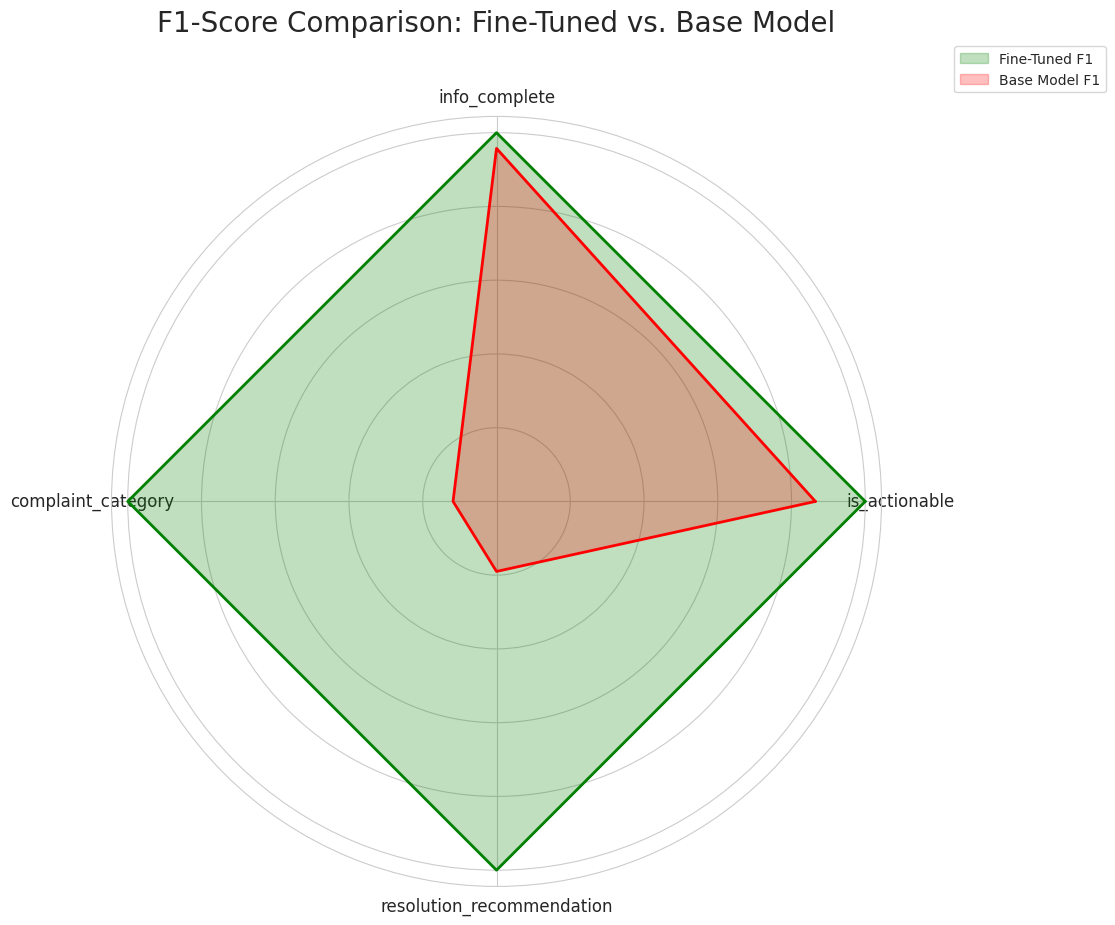

Radar chart saved to ./gemma-3-270m-fashion-multitask_v1/evaluation_results/f1_score_radar_chart.png


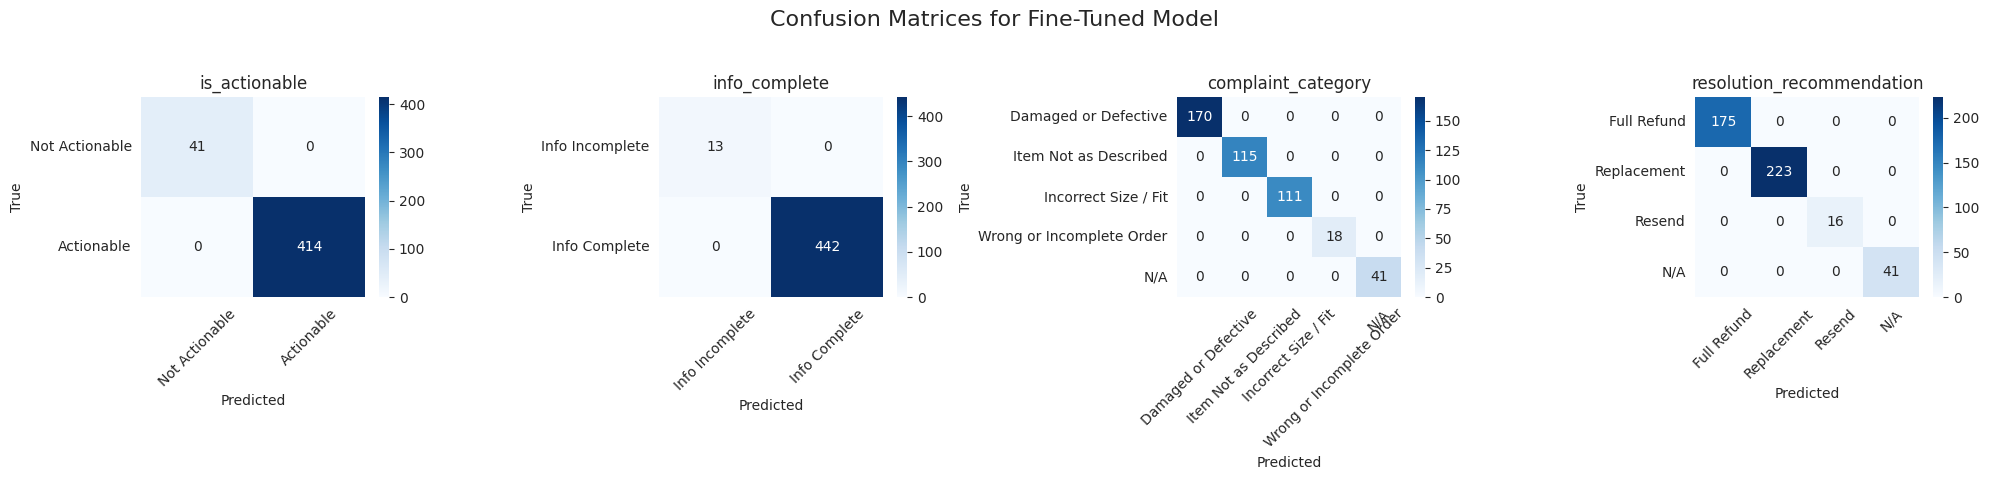

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/config.json
Model config Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 640,
  "initializer_range": 0.02,
  "intermediate_size": 2048,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    

Confusion matrices saved to ./gemma-3-270m-fashion-multitask_v1/evaluation_results/confusion_matrices.png

--- Pushing Model to Hub: ShovalBenjer/gemma-3-270m-fashion-multitask_v1 ---
Re-loading fine-tuned model for pushing to Hub...
Loading fine-tuned model...
GCR: QLoRA enabled. Using device_map='auto' and compute_dtype=torch.bfloat16


target_dtype {target_dtype} is replaced by `CustomDtype.INT4` for 4-bit BnB quantization
All model checkpoint weights were used when initializing Gemma3ForCausalLM.

All the weights of Gemma3ForCausalLM were initialized from the model checkpoint at google/gemma-3-270m.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Gemma3ForCausalLM for predictions without further training.
loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--google--gemma-3-270m/snapshots/9b0cfec892e2bc2afd938c98eabe4e4a7b1e0ca1/generation_config.json
Generate config GenerationConfig {
  "cache_implementation": "hybrid",
  "do_sample": true,
  "top_k": 64,
  "top_p": 0.95
}



GCR: Base model loaded. Hidden_size: 640
Loading trained classification heads from: ./gemma-3-270m-fashion-multitask_v1/classification_heads.pth
Applying LoRA adapter from: ./gemma-3-270m-fashion-multitask_v1/lora_adapter
Model loaded, cast to torch.bfloat16, and moved to cuda:0.


Uploading the following files to ShovalBenjer/gemma-3-270m-fashion-multitask_v1: README.md,adapter_config.json,adapter_model.safetensors


...

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...fashion-multitask_v1/tokenizer.json: 100%|##########| 33.4MB / 33.4MB            

  ...ashion-multitask_v1/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

Tokenizer pushed successfully.

✅ Successfully pushed all artifacts to: https://huggingface.co/ShovalBenjer/gemma-3-270m-fashion-multitask_v1
Final model cleaned from memory.

Evaluation and deployment process complete.


In [10]:
# Cell 10: Full Evaluation, Visualization & Push to Hub (Rewritten for New Project)

# --- 1. Imports and Setup ---
print("--- 1. Setting up for Evaluation ---")
import torch, gc, os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, traceback
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from huggingface_hub import HfApi, HfFolder, create_repo, upload_file
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from peft import PeftModel

# Defensive checks
if 'GemmaComplaintResolver' not in locals():
    raise NameError("The 'GemmaComplaintResolver' class is not defined. Please ensure Cell 5 has been run.")
if 'processed_eval_dataset' not in locals() or processed_eval_dataset is None:
     raise NameError("The 'processed_eval_dataset' is not defined. Please ensure Cell 6 has been run successfully.")

# MODIFIED: This dictionary maps our internal task names to the human-readable labels for plotting.
# It's crucial that this matches the lists from Cell 4.
TASK_TO_LABELS_MAP = {
    "is_actionable": ["Not Actionable", "Actionable"],
    "info_complete": ["Info Incomplete", "Info Complete"],
    "complaint_category": COMPLAINT_CATEGORIES,
    "resolution_recommendation": RESOLUTION_RECOMMENDATIONS,
}

# --- 2. Helper Functions for Evaluation ---
def load_inference_model(is_finetuned: bool):
    """Loads a model for inference, either the fine-tuned version or the base version."""
    print(f"Loading {'fine-tuned' if is_finetuned else 'base'} model...")
    model_config = AutoConfig.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)

    inference_model = GemmaComplaintResolver(
        base_model_name_or_path=STUDENT_MODEL_ID,
        num_labels_dict=num_labels_dict_global,
        model_config_for_base_loading=model_config,
    )

    if is_finetuned:
        if not os.path.exists(CLASSIFICATION_HEADS_PATH):
            raise FileNotFoundError(f"Heads not found at {CLASSIFICATION_HEADS_PATH}")
        print(f"Loading trained classification heads from: {CLASSIFICATION_HEADS_PATH}")
        head_weights = torch.load(CLASSIFICATION_HEADS_PATH, map_location='cpu')
        inference_model.load_state_dict(head_weights, strict=False)

        print(f"Applying LoRA adapter from: {LORA_ADAPTER_DIR}")
        inference_model = PeftModel.from_pretrained(inference_model, LORA_ADAPTER_DIR)

    compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    inference_model.to(dtype=compute_dtype, device=DEVICE)
    inference_model.eval()
    print(f"Model loaded, cast to {compute_dtype}, and moved to {inference_model.device}.")
    return inference_model

@torch.no_grad()
def get_all_predictions(model, dataset, tokenizer):
    """Generates predictions for all tasks."""
    tasks_to_eval = list(TASK_TO_LABELS_MAP.keys())
    predictions = {task: [] for task in tasks_to_eval}
    ground_truths = {task: [] for task in tasks_to_eval}

    for example in tqdm(dataset, desc=f"Predicting with model"):
        input_text = example['text_for_lm']
        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH_TRAINING).to(DEVICE)
        outputs = model(**inputs)

        for task in tasks_to_eval:
            logits_key = f"logits_{task}"
            label_key = f"label_{task}"
            if logits_key in outputs:
                logits = outputs[logits_key]
                pred = torch.argmax(logits, dim=-1).cpu().item()
                true_label = example[label_key]
                if true_label != -100:
                    predictions[task].append(pred)
                    ground_truths[task].append(true_label)
    return predictions, ground_truths

# --- 3. Main Sequential Evaluation Logic ---
TASKS = list(TASK_TO_LABELS_MAP.keys())
new_model_repo_id = f"{HfApi().whoami()['name']}/{os.path.basename(FINE_TUNED_MODEL_DIR)}"
print(f"Evaluation tasks: {TASKS}")
print(f"Final model will be pushed to: https://huggingface.co/{new_model_repo_id}")

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_SAVE_PATH)

# --- Step 3.1: Evaluate Fine-Tuned Model ---
print("\n--- Evaluating Fine-Tuned Model ---")
finetuned_model = load_inference_model(is_finetuned=True)
finetuned_preds, finetuned_trues = get_all_predictions(finetuned_model, processed_eval_dataset, tokenizer)
del finetuned_model; gc.collect(); torch.cuda.empty_cache()

# --- Step 3.2: Evaluate Base Model (for comparison) ---
print("\n--- Evaluating Base Model (for comparison) ---")
base_model_for_eval = load_inference_model(is_finetuned=False)
base_preds, base_trues = get_all_predictions(base_model_for_eval, processed_eval_dataset, tokenizer)
del base_model_for_eval; gc.collect(); torch.cuda.empty_cache()

# --- 4. Metrics Calculation and Visualization ---
print("\n--- Calculating and Visualizing Performance Metrics ---")
def calculate_metrics(predictions, truths):
    results = {}
    for task in TASKS:
        if not truths.get(task): continue
        precision, recall, f1, _ = precision_recall_fscore_support(truths[task], predictions[task], average='weighted', zero_division=0)
        accuracy = accuracy_score(truths[task], predictions[task])
        results[task] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}
    return results

finetuned_metrics = calculate_metrics(finetuned_preds, finetuned_trues)
base_metrics = calculate_metrics(base_preds, base_trues)
metrics_df = pd.concat({
    "Fine-Tuned Model": pd.DataFrame(finetuned_metrics).T,
    "Base Model (Untrained Heads)": pd.DataFrame(base_metrics).T
}, axis=1).fillna(0)

print("\n--- Comparative Metrics ---")
print(metrics_df.to_string())
metrics_df.to_csv(os.path.join(EVAL_RESULTS_DIR, "comparative_metrics.csv"))
print(f"\nMetrics saved to {os.path.join(EVAL_RESULTS_DIR, 'comparative_metrics.csv')}")

# A. Radar Chart for F1-Score Comparison
labels = list(finetuned_metrics.keys())
finetuned_f1 = [finetuned_metrics[task]['F1-Score'] for task in labels]
base_f1 = [base_metrics.get(task, {}).get('F1-Score', 0) for task in labels]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
finetuned_f1 += finetuned_f1[:1]; base_f1 += base_f1[:1]; angles += angles[:1]
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.fill(angles, finetuned_f1, color='green', alpha=0.25, label='Fine-Tuned F1')
ax.plot(angles, finetuned_f1, color='green', linewidth=2)
ax.fill(angles, base_f1, color='red', alpha=0.25, label='Base Model F1')
ax.plot(angles, base_f1, color='red', linewidth=2)
ax.set_yticklabels([]); ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, size=12)
plt.title('F1-Score Comparison: Fine-Tuned vs. Base Model', size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
radar_chart_path = os.path.join(EVAL_RESULTS_DIR, "f1_score_radar_chart.png")
plt.savefig(radar_chart_path, bbox_inches='tight'); plt.show()
print(f"Radar chart saved to {radar_chart_path}")

# B. Confusion Matrices
num_tasks = len(TASKS)
fig, axes = plt.subplots(1, num_tasks, figsize=(num_tasks * 5, 5))
fig.suptitle('Confusion Matrices for Fine-Tuned Model', fontsize=16)
for i, task in enumerate(TASKS):
    ax = axes[i]
    class_labels = TASK_TO_LABELS_MAP.get(task, [])
    cm = confusion_matrix(finetuned_trues[task], finetuned_preds[task], labels=range(len(class_labels)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_labels, yticklabels=class_labels)
    ax.set_title(task); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
cm_path = os.path.join(EVAL_RESULTS_DIR, "confusion_matrices.png")
plt.savefig(cm_path, bbox_inches='tight'); plt.show()
print(f"Confusion matrices saved to {cm_path}")

# --- 5. Push to Hugging Face Hub ---
print(f"\n--- Pushing Model to Hub: {new_model_repo_id} ---")
final_model_to_push = None
try:
    print("Re-loading fine-tuned model for pushing to Hub...")
    final_model_to_push = load_inference_model(is_finetuned=True)
    repo_url = create_repo(repo_id=new_model_repo_id, exist_ok=True, private=False)

    # This is the step that requires a valid login token
    final_model_to_push.push_to_hub(new_model_repo_id)
    print("LoRA adapter pushed successfully.")

    api = HfApi()
    api.upload_file(path_or_fileobj=CLASSIFICATION_HEADS_PATH, path_in_repo="classification_heads.pth", repo_id=new_model_repo_id)
    print("Classification heads pushed successfully.")

    tokenizer.push_to_hub(new_model_repo_id)
    print("Tokenizer pushed successfully.")
    print(f"\n✅ Successfully pushed all artifacts to: {repo_url.url}")

except Exception as e:
    print(f"❌ An error occurred while pushing to the Hub: {e}")
    print("REMINDER: This may be due to the missing Hugging Face login token. You can log in manually and re-run this cell.")
    traceback.print_exc()
finally:
    if final_model_to_push is not None:
        del final_model_to_push; gc.collect(); torch.cuda.empty_cache()
        print("Final model cleaned from memory.")

print("\nEvaluation and deployment process complete.")